In [1]:
import os
import pandas as pd
import pyvista as pv
import matplotlib.pyplot as plt
import numpy as np

In [2]:
abm_path = os.path.dirname(os.getcwd()) + "/PDAC/sim/outputs/abm/"
pde_path = os.path.dirname(os.getcwd()) + "/PDAC/sim/outputs/pde/"

abm_files = sorted(os.listdir(abm_path))
pde_files = sorted(os.listdir(pde_path))

In [3]:
abms = []
pdes = []
slice = 25
for i in range(0,100,10):
    temp = pd.read_csv(abm_path + abm_files[i], header = 0)
    temp = temp[temp['z'] == slice].copy()
    abms.append(temp)
    temp = pd.read_csv(pde_path + pde_files[i], header = 0)
    temp = temp[temp['z'] == slice].copy()
    pdes.append(temp)

In [4]:
print(temp)

        x   y   z  O2  IFN  IL2  IL10  TGFB  CCL2  ARGI  NO          IL12  \
62500   0   0  25   0    0    0     0     0     0     0   0  9.624000e-11   
62501   1   0  25   0    0    0     0     0     0     0   0  9.679380e-11   
62502   2   0  25   0    0    0     0     0     0     0   0  9.789800e-11   
62503   3   0  25   0    0    0     0     0     0     0   0  9.954580e-11   
62504   4   0  25   0    0    0     0     0     0     0   0  1.017260e-10   
...    ..  ..  ..  ..  ...  ...   ...   ...   ...   ...  ..           ...   
64995  45  49  25   0    0    0     0     0     0     0   0  6.997450e-10   
64996  46  49  25   0    0    0     0     0     0     0   0  7.052850e-10   
64997  47  49  25   0    0    0     0     0     0     0   0  7.094800e-10   
64998  48  49  25   0    0    0     0     0     0     0   0  7.122540e-10   
64999  49  49  25   0    0    0     0     0     0     0   0  7.136240e-10   

       VEGFA  
62500      0  
62501      0  
62502      0  
62503      0  


In [5]:
points = []
clouds = []
for i in range(10):
    points.append(abms[i][['x','y','z']].to_numpy().astype(np.float32))
    clouds.append(points[i])

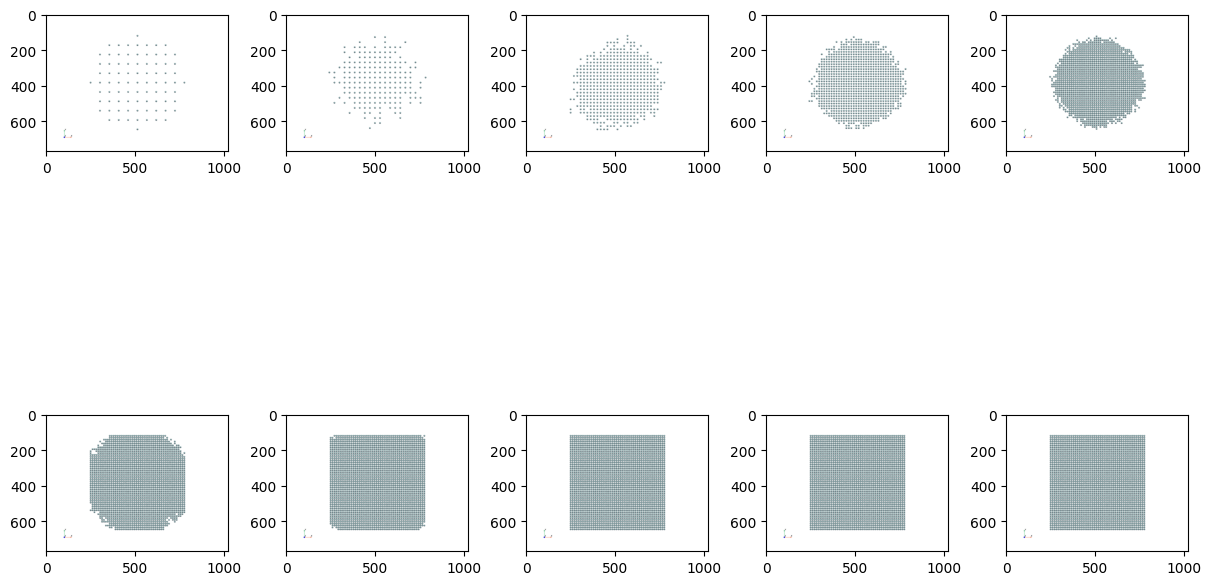

In [6]:
fig, axes = plt.subplots(2,5,figsize=(12,8),layout='constrained')
cnt = 0
for i, ax_row in enumerate(axes):
    for j, ax in enumerate(ax_row):
        p = pv.Plotter()
        p.add_mesh(clouds[cnt],point_size=10,render_points_as_spheres=True)
        p.add_axes()
        p.view_xy()
        img = p.screenshot(transparent_background=False)
        p.close()
        ax.imshow(img)
        cnt+=1

In [7]:
substrates = np.zeros((50,50,10,10))
names = ['O2','IFN','IL2','IL10','TGFB','CCL2','ARGI','NO','IL12','VEGFA']
for i in range(10):
    for index, row in pdes[i].iterrows():
        x = row['x'].astype(np.int32)
        y = row['y'].astype(np.int32)
        values = row[names].to_numpy()
        substrates[y,x,:,i] = values
         

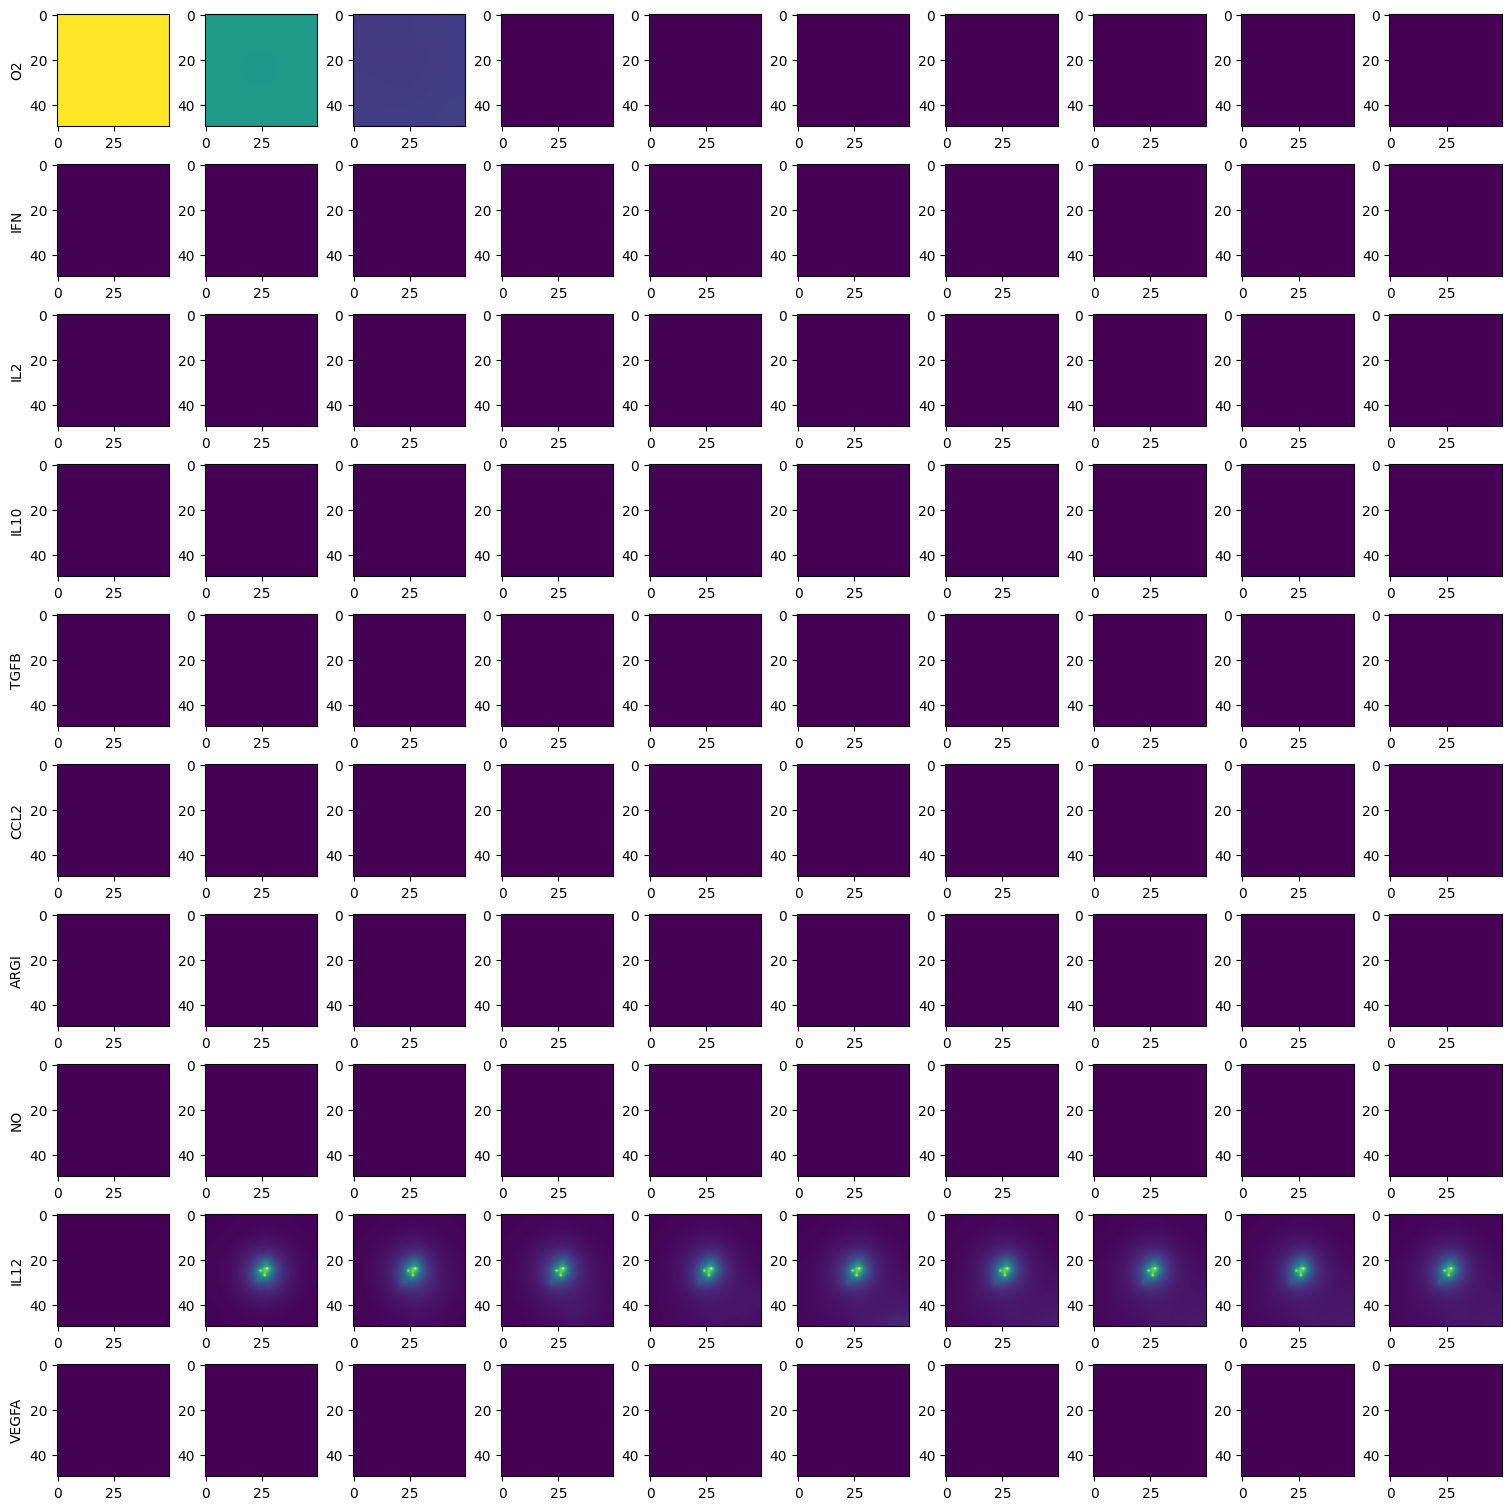

In [8]:
mins = np.min(np.min(np.min(substrates,axis=3),axis=0),axis=0)
maxes = np.max(np.max(np.max(substrates,axis=3),axis=0),axis=0)

fig, ax = plt.subplots(10,10,figsize=(15,15),layout='constrained')
for i in range(10):
    for j in range(10):
        ax[i][j].imshow(substrates[:,:,i,j], vmin = 0, vmax = maxes[i])
        if j == 0:
            ax[i][j].set_ylabel(names[i])
